# Topic Modeling (LDA & NMF)

Topic modeling is an unsupervised machine learning technique that automatically discovers hidden thematic structures across a large collection of text documents. Rather than manually reading thousands
of reviews, topic modeling lets us identify what players commonly talk about across 315 games and 900,000+ reviews.

We implement and compare two topic modeling approaches:

| Method | Input | Approach | Topics |
|---|---|---|---|
| LDA (Latent Dirichlet Allocation) | Bag of Words | Probabilistic | 10 |
| NMF (Non-negative Matrix Factorization) | TF-IDF | Algebraic | 15 |

**Three methodological decisions made in this Notebook:**

1. **Per-game review capping (2,000 max):** The full dataset has unequal game representation from 32,660 reviews (Terraria) to just 2 reviews (三国群英传8). Without capping, dominant games monopolize topic vocabulary. We cap at 2,000 reviews per game for building topic models only. Topic assignment is done on the full dataset afterward.

2. **Negation words excluded from vectorizers:** Words like "not", "dont", "cant" are preserved in our cleaned text for Notebook 5 sentiment modeling but excluded at the vectorizer level here.
   In topic modeling, negations create catch-all negative language buckets rather than meaningful themes.

3. **NMF uses 15 topics vs LDA's 10:** Initial runs showed NMF creating one dominant catch-all topic absorbing 47.6% of reviews. Increasing to 15 topics forces NMF to discover more granular, specific themes.

### Load Dependencies & Notebook 3 Output

We load all libraries needed for topic modeling and the preprocessed dataset saved at the end of Notebook 3.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_parquet('../data/steam_text_mining_nb3.parquet')

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")

Rows    : 919,083
Columns : ['review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours', 'review_cleaned', 'review_cleaned_sentiment', 'word_count_raw', 'word_count_cleaned', 'word_count_conservative', 'ttr', 'is_helpful']


### Cap Reviews Per Game (2,000 max)

The full dataset has highly unequal game representation after English filtering, from 32,660 reviews (Terraria) to just 2 reviews
(三国群英传8). Without capping, dominant games monopolize topic vocabulary and LDA/NMF discover game-specific themes rather than platform-wide patterns.

We cap each game at 2,000 reviews to ensure all 315 games contribute proportionally to topic discovery. This capped dataset is used exclusively for building and training the topic models.
Topic assignment in a later step is performed on the full dataset.

In [56]:
REVIEWS_PER_GAME_CAP = 2000

df_topics = (
    df.groupby('app_name')
      .apply(lambda x: x.sample(min(len(x), REVIEWS_PER_GAME_CAP), random_state=42))
      .reset_index(level=0)   
)

print(f"Full dataset rows    : {len(df):,}")
print(f"Capped dataset rows  : {len(df_topics):,}")
print(f"Unique games         : {df_topics['app_name'].nunique()}")
print(f"\nTop 5 games after capping:")
print(df_topics['app_name'].value_counts().head())
print(f"\nBottom 5 games after capping:")
print(df_topics['app_name'].value_counts().tail())

Full dataset rows    : 919,083
Capped dataset rows  : 362,351
Unique games         : 315

Top 5 games after capping:
app_name
A Hat in Time               2000
ARK: Survival Evolved       2000
ATLAS                       2000
Age of Empires II (2013)    2000
American Truck Simulator    2000
Name: count, dtype: int64

Bottom 5 games after capping:
app_name
DRAGON QUEST HEROES™ II                  35
Battle Royale Trainer                    27
Senren＊Banka                             25
Neon Hardcorps                            6
三国群英传8 Heroes of the Three Kingdoms 8     1
Name: count, dtype: int64


### Define Negation Stopwords for Vectorizers

Negation words like "not", "dont", "cant" are preserved in our `review_cleaned` text for use in Notebook 5 sentiment modeling. However, for topic modeling they cause problems, they are so
universally common across all reviews that they create catch-all negative language buckets rather than meaningful themes.

We define a negation stopword list to pass to both vectorizers. the actual text in `review_cleaned` remains unchanged.

In [57]:
negation_stopwords = [
    'not', 'dont', 'cant', 'wont', 'didnt', 'doesnt',
    'wasnt', 'isnt', 'arent', 'never', 'nor', 'no',
    'nothing', 'neither', 'hardly', 'wouldnt', 'couldnt',
    'shouldnt', 'hasnt', 'havent', 'hadnt'
]

sentiment_stopwords = [
    'good', 'great', 'amazing', 'awesome', 'love', 'loved',
    'best', 'nice', 'cool', 'pretty', 'fantastic', 'wonderful',
    'excellent', 'brilliant', 'incredible', 'perfect', 'beautiful',
    'lovely', 'superb', 'outstanding', 'favorite', 'favourite',
    'highly', 'absolutely', 'definitely', 'totally', 'super',
    'must', 'highly',

    'bad', 'hate', 'worst', 'terrible', 'awful', 'horrible',
    'boring', 'disappointing', 'disappointing', 'poor', 'shit',
    'fuck', 'fucking', 'damn', 'hell',

    'overall', 'literally', 'seriously', 'honestly', 'basically',
    'simply', 'yeah', 'yes', 'guess', 'though', 'thats'
]

vectorizer_stopwords = negation_stopwords + sentiment_stopwords
print(f"Negation stopwords defined : {len(negation_stopwords)} words")
print(f"Sentiment stopwords : {len(sentiment_stopwords)}")
print(f"Total excluded      : {len(vectorizer_stopwords)}")
print(f"{vectorizer_stopwords}")

Negation stopwords defined : 21 words
Sentiment stopwords : 55
Total excluded      : 76
['not', 'dont', 'cant', 'wont', 'didnt', 'doesnt', 'wasnt', 'isnt', 'arent', 'never', 'nor', 'no', 'nothing', 'neither', 'hardly', 'wouldnt', 'couldnt', 'shouldnt', 'hasnt', 'havent', 'hadnt', 'good', 'great', 'amazing', 'awesome', 'love', 'loved', 'best', 'nice', 'cool', 'pretty', 'fantastic', 'wonderful', 'excellent', 'brilliant', 'incredible', 'perfect', 'beautiful', 'lovely', 'superb', 'outstanding', 'favorite', 'favourite', 'highly', 'absolutely', 'definitely', 'totally', 'super', 'must', 'highly', 'bad', 'hate', 'worst', 'terrible', 'awful', 'horrible', 'boring', 'disappointing', 'disappointing', 'poor', 'shit', 'fuck', 'fucking', 'damn', 'hell', 'overall', 'literally', 'seriously', 'honestly', 'basically', 'simply', 'yeah', 'yes', 'guess', 'though', 'thats']


### Build Bag of Words Matrix (for LDA)

LDA requires a Bag of Words matrix as input: a matrix where each row represents a review and each column represents a word, with values being raw word counts.

We use sklearn's `CountVectorizer` with the following constraints:
- **min_df=10**: ignore words appearing in fewer than 10 reviews
- **max_df=0.95**: ignore words in more than 95% of reviews
- **max_features=10,000**: top 10,000 words by frequency
- **stop_words=negation_stopwords**: exclude negation words at the vectorizer level to improve topic quality

In [58]:
print("Building Bag of Words matrix for LDA...")

bow_vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=10,
    max_features=10_000,
    stop_words=vectorizer_stopwords
)

bow_matrix = bow_vectorizer.fit_transform(df_topics['review_cleaned'])
bow_vocab  = bow_vectorizer.get_feature_names_out()

print(f"BoW matrix built")
print(f"Shape      : {bow_matrix.shape}")
print(f"Reviews    : {bow_matrix.shape[0]:,}")
print(f"Vocabulary : {bow_matrix.shape[1]:,} words")
print(f"Non-zero   : {bow_matrix.nnz:,} entries")

Building Bag of Words matrix for LDA...
BoW matrix built
Shape      : (362351, 10000)
Reviews    : 362,351
Vocabulary : 10,000 words
Non-zero   : 6,115,013 entries


### Build TF-IDF Matrix (for NMF)

NMF requires a TF-IDF matrix as input. TF-IDF weights words by how distinctive they are rewarding words frequent in a specific review but rare across the corpus, producing cleaner topic separations
than raw word counts.

We apply the same negation stopwords and vocabulary constraints as the BoW matrix to ensure a consistent and fair model comparison.

In [59]:
print("Building TF-IDF matrix for NMF...")

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=10,
    max_features=10_000,
    stop_words=vectorizer_stopwords
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_topics['review_cleaned'])
tfidf_vocab  = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix built")
print(f"Shape      : {tfidf_matrix.shape}")
print(f"Reviews    : {tfidf_matrix.shape[0]:,}")
print(f"Vocabulary : {tfidf_matrix.shape[1]:,} words")
print(f"Non-zero   : {tfidf_matrix.nnz:,} entries")

Building TF-IDF matrix for NMF...
TF-IDF matrix built
Shape      : (362351, 10000)
Reviews    : 362,351
Vocabulary : 10,000 words
Non-zero   : 6,115,013 entries


### Train LDA Model

We train a Latent Dirichlet Allocation model with 10 topics. LDA treats each review as a probabilistic mixture of topics and each topic as a probabilistic mixture of words, discovering
latent themes across the entire corpus.

**Hyperparameters:**
- **n_components=10**: number of topics to discover
- **max_iter=15**: maximum training iterations
- **learning_method='online'**: memory efficient for large datasets
- **random_state=42**: ensures reproducible results
- **n_jobs=-1**: uses all available CPU cores


In [60]:
print("Training LDA model (10 topics)...")

lda_model = LatentDirichletAllocation(
    n_components=10,
    max_iter=15,
    learning_method='online',
    random_state=42,
    n_jobs=-1
)

lda_model.fit(bow_matrix)

print(f"LDA model trained")
print(f"Topics     : {lda_model.n_components}")
print(f"Perplexity : {lda_model.perplexity(bow_matrix):.2f}")

Training LDA model (10 topics)...
LDA model trained
Topics     : 10
Perplexity : 2741.02


### Display LDA Topics

We extract the top 15 words for each LDA topic and display them in a clean formatted table. Based on these words we will manually assign a descriptive label to each topic in the next step.


In [61]:
def display_topics(model, vocab, n_words=15, model_name='LDA'):
    print(f"{model_name} Topics — Top {n_words} Words\n")
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_words = [vocab[i] for i in topic.argsort()[:-n_words-1:-1]]
        topics[f'Topic {idx+1}'] = top_words
        print(f"Topic {idx+1:2d}: {', '.join(top_words)}")
    return topics

lda_topics = display_topics(lda_model, bow_vocab,
                             n_words=15, model_name='LDA')

LDA Topics — Top 15 Words

Topic  1: world, map, quest, combat, turn, building, open, like, simulator, side, park, ship, animal, explore, system
Topic  2: worth, bug, new, year, money, update, issue, content, better, price, since, far, buy, wait, sale
Topic  3: like, feel, enemy, first, take, new, find, point, start, different, system, weapon, around, something, there
Topic  4: friend, multiplayer, need, like, coop, online, mode, computer, epic, work, better, suck, graphic, shooter, controller
Topic  5: story, character, gameplay, graphic, like, series, music, experience, feel, style, puzzle, interesting, first, level, ever
Topic  6: dark, hard, soul, die, run, gun, warhammer, god, dead, guy, big, car, skyrim, soon, man
Topic  7: mod, ever, war, kill, community, server, city, battle, video, although, faction, watch, army, rts, empire
Topic  8: like, old, life, total, feel, voice, better, finished, half, franchise, performance, acting, look, fan, year
Topic  9: fps, minute, funny, scree

### Manually Label LDA Topics

Based on the top 15 words for each topic from the previous cell, we assign human-readable labels that best capture the theme each topic represents.

In [63]:
lda_topic_labels = {
    0  : 'Open World & Strategy RPG',
    1  : 'Game Updates & Value Assessment',
    2  : 'Early Game Experience & Mechanics',
    3  : 'Multiplayer & Co-op Experience',
    4  : 'Core Game Quality & Experience',
    5  : 'Challenging Action & Combat Games',
    6  : 'Strategy, War & Modding Community',
    7  : 'Nostalgia & Series Comparisons',
    8  : 'FPS & Casual Gaming',
    9  : 'Survival Games & DLC Purchases',
}

print("LDA Topic Labels\n")
for topic_id, label in lda_topic_labels.items():
    words = ', '.join(lda_topics[f'Topic {topic_id+1}'][:8])
    print(f"Topic {topic_id+1:2d} | {label:<40} | {words}")

LDA Topic Labels

Topic  1 | Open World & Strategy RPG                | world, map, quest, combat, turn, building, open, like
Topic  2 | Game Updates & Value Assessment          | worth, bug, new, year, money, update, issue, content
Topic  3 | Early Game Experience & Mechanics        | like, feel, enemy, first, take, new, find, point
Topic  4 | Multiplayer & Co-op Experience           | friend, multiplayer, need, like, coop, online, mode, computer
Topic  5 | Core Game Quality & Experience           | story, character, gameplay, graphic, like, series, music, experience
Topic  6 | Challenging Action & Combat Games        | dark, hard, soul, die, run, gun, warhammer, god
Topic  7 | Strategy, War & Modding Community        | mod, ever, war, kill, community, server, city, battle
Topic  8 | Nostalgia & Series Comparisons           | like, old, life, total, feel, voice, better, finished
Topic  9 | FPS & Casual Gaming                      | fps, minute, funny, screen, time, day, right, let
Top

### Train NMF Model (15 Topics)

We train NMF with 15 topics more than LDA's 10. Initial runs with 10 topics showed NMF creating one dominant catch-all topic absorbing 47.6% of all reviews, anchored by generic negative language rather than a specific theme. Increasing to 15 topics forces NMF to discover more granular and specific themes.

The models are evaluated purely on coherence score, the better score determines which topic assignments are used in Notebook 5.

**Hyperparameters:**
- **n_components=15**: increased from 10 to break catch-all topic
- **init='nndsvda'**: deterministic initialization for stability
- **random_state=42**: ensures reproducible results
- **max_iter=500**: sufficient iterations for convergence

In [64]:
print("Training NMF model (15 topics)...")

nmf_model = NMF(
    n_components=15,
    init='nndsvda',
    random_state=42,
    max_iter=500
)

nmf_model.fit(tfidf_matrix)

print(f"NMF model trained")
print(f"Topics               : {nmf_model.n_components}")
print(f"Reconstruction error : {nmf_model.reconstruction_err_:.4f}")

Training NMF model (15 topics)...
NMF model trained
Topics               : 15
Reconstruction error : 565.4120


### Display & Label NMF Topics

We extract the top 15 words for each of the 15 NMF topics and assign descriptive labels. With 15 topics we expect previously
merged themes to now appear as distinct, specific topics, particularly within the negative review space.

In [65]:
nmf_topics = display_topics(nmf_model, tfidf_vocab,
                             n_words=15, model_name='NMF')

NMF Topics — Top 15 Words

Topic  1: first, new, feel, character, level, little, world, take, give, see, could, experience, keep, different, combat
Topic  2: ever, greatest, probably, rpg, seen, strategy, spent, hand, created, simulator, survival, fps, horror, easily, indie
Topic  3: friend, coop, especially, alone, funny, solo, online, multiplayer, lot, together, group, blast, laugh, server, family
Topic  4: like, feel, look, minecraft, soul, stuff, liked, dark, park, kinda, seems, old, skyrim, felt, anyone
Topic  5: buy, sale, already, dlc, regret, please, reading, stop, right, bought, dlcs, money, full, suck, free
Topic  6: story, character, gameplay, line, interesting, combat, music, soundtrack, main, short, art, ending, puzzle, world, mechanic
Topic  7: worth, money, price, sale, penny, buying, wait, full, dollar, dlc, waste, cent, short, spent, buck
Topic  8: better, first, getting, could, original, get, csgo, version, expected, pubg, keep, update, fortnite, gta, make
Topic  9: h

In [67]:
nmf_topic_labels = {
    0  : 'First Impressions & Game World',
    1  : 'Top Rated RPG & Strategy Games',
    2  : 'Social & Multiplayer Experience',
    3  : 'Sandbox & Souls-like Games',
    4  : 'Purchase Advice & DLC Concerns',
    5  : 'Story, Gameplay & Soundtrack Quality',
    6  : 'Value for Money & Pricing',
    7  : 'Version & Sequel Comparisons',
    8  : 'Game Difficulty & Skill Progression',
    9  : 'Modding Community & Workshop',
    10 : 'Overall Game Quality & Immersion',
    11 : 'Technical Issues & Fix Requests',
    12 : 'Game Longevity & Long-term Play',
    13 : 'Game Franchise & Series Reviews',
    14 : 'Remakes & Simulator Experiences',
}

print("NMF Topic Labels\n")
for topic_id, label in nmf_topic_labels.items():
    words = ', '.join(nmf_topics[f'Topic {topic_id+1}'][:8])
    print(f"Topic {topic_id+1:2d} | {nmf_topic_labels[topic_id]:<40} | {words}")

NMF Topic Labels

Topic  1 | First Impressions & Game World           | first, new, feel, character, level, little, world, take
Topic  2 | Top Rated RPG & Strategy Games           | ever, greatest, probably, rpg, seen, strategy, spent, hand
Topic  3 | Social & Multiplayer Experience          | friend, coop, especially, alone, funny, solo, online, multiplayer
Topic  4 | Sandbox & Souls-like Games               | like, feel, look, minecraft, soul, stuff, liked, dark
Topic  5 | Purchase Advice & DLC Concerns           | buy, sale, already, dlc, regret, please, reading, stop
Topic  6 | Story, Gameplay & Soundtrack Quality     | story, character, gameplay, line, interesting, combat, music, soundtrack
Topic  7 | Value for Money & Pricing                | worth, money, price, sale, penny, buying, wait, full
Topic  8 | Version & Sequel Comparisons             | better, first, getting, could, original, get, csgo, version
Topic  9 | Game Difficulty & Skill Progression      | hard, easy, learn, m

### Compute Coherence Scores

Coherence score measures how semantically similar the top words within each topic are to each other. A higher score indicates more interpretable and meaningful topics.

We compute the **C_v coherence score** (range 0 to 1) for both models using Gensim, providing an objective quantitative basis for comparing LDA and NMF, directly addressing our proposal's
topic modeling evaluation metric.

In [68]:
def compute_coherence(model, vocab, texts, n_words=15):
    topics_words = []
    for topic in model.components_:
        top_words = [vocab[i] for i in topic.argsort()[:-n_words-1:-1]]
        topics_words.append(top_words)

    # Build gensim dictionary from tokenized texts
    tokenized  = [text.split() for text in texts]
    dictionary = corpora.Dictionary(tokenized)

    coherence_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

texts = df['review_cleaned'].dropna().tolist()

print("Computing LDA coherence score...")
lda_coherence = compute_coherence(lda_model, bow_vocab, texts)
print(f"LDA  Coherence (C_v) : {lda_coherence:.4f}")

print("\nComputing NMF coherence score...")
nmf_coherence = compute_coherence(nmf_model, tfidf_vocab, texts)
print(f"NMF  Coherence (C_v) : {nmf_coherence:.4f}")

winner = 'LDA' if lda_coherence > nmf_coherence else 'NMF'
print(f"\n{'='*45}")
print(f"  Better model : {winner}")
print(f"  Score diff   : {abs(lda_coherence - nmf_coherence):.4f}")
print(f"{'='*45}")

Computing LDA coherence score...
LDA  Coherence (C_v) : 0.4722

Computing NMF coherence score...
NMF  Coherence (C_v) : 0.5121

  Better model : NMF
  Score diff   : 0.0400


### Visualize Topic Word Distributions

We visualize the top 10 words for each topic as horizontal bar charts with bar length representing word weight within that topic.

LDA topics are arranged in a 2×5 grid (10 topics).
NMF topics are arranged in a 3×5 grid (15 topics).

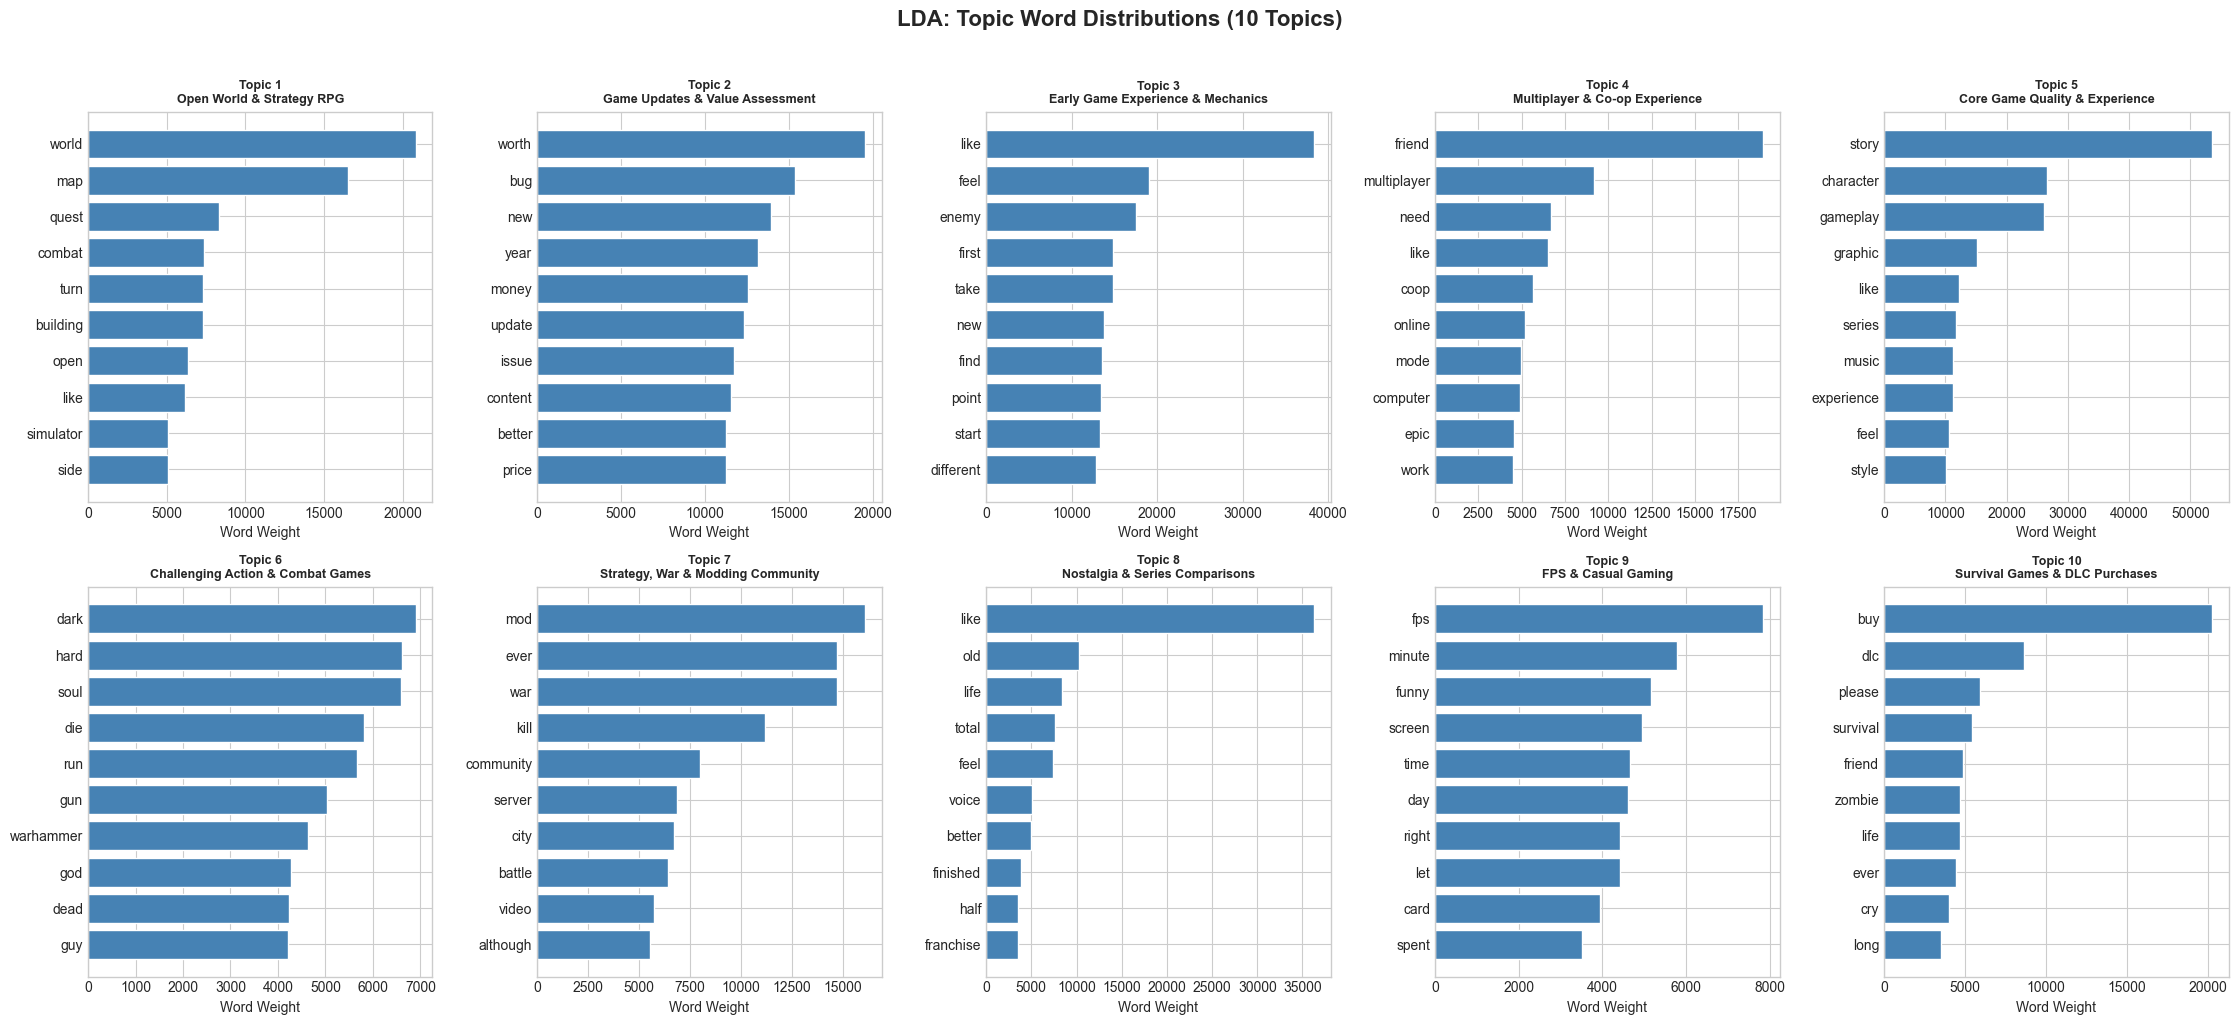

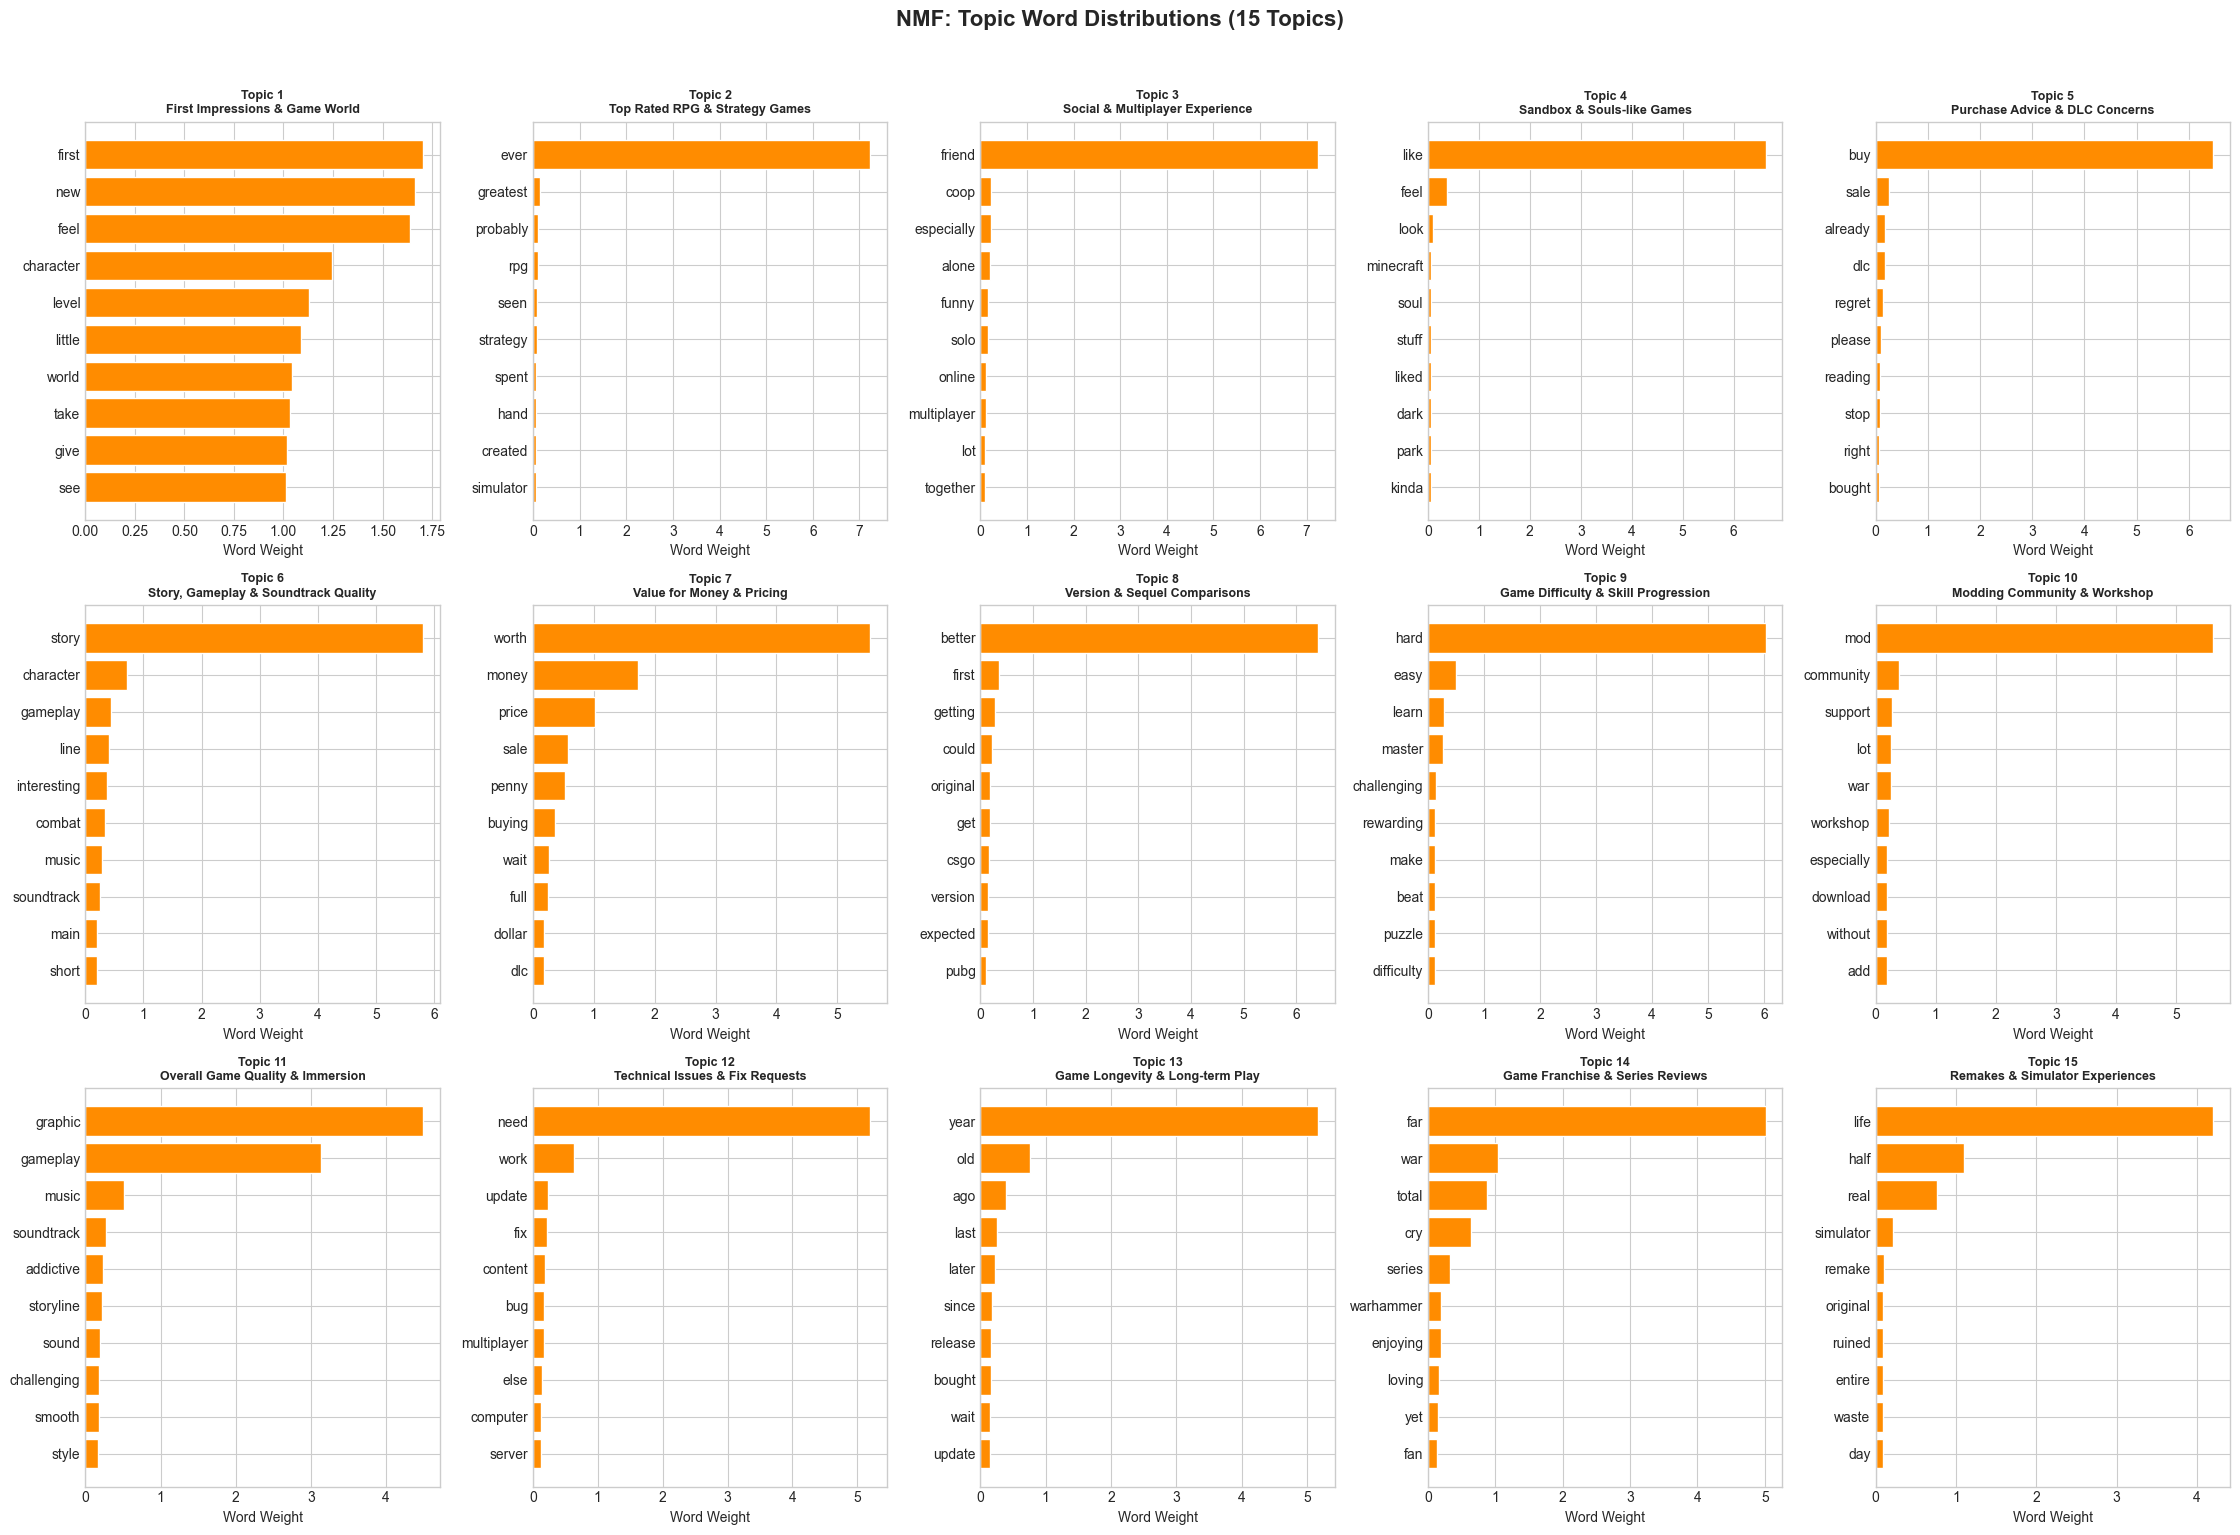

In [70]:
def plot_topic_words(model, vocab, labels, title, n_words=10, color='steelblue', n_rows=2, n_cols=5):

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 4.5, n_rows * 5)
    )
    axes = axes.flatten()

    for idx, (topic, ax) in enumerate(
            zip(model.components_, axes)):
        top_indices = topic.argsort()[:-n_words-1:-1]
        top_words   = [vocab[i] for i in top_indices]
        top_weights = [topic[i] for i in top_indices]

        ax.barh(top_words, top_weights,
                color=color, edgecolor='white')
        ax.set_title(f"Topic {idx+1}\n{labels[idx]}",
                     fontsize=9, fontweight='bold')
        ax.invert_yaxis()
        ax.set_xlabel('Word Weight')

    # Hide unused subplots if any
    for idx in range(len(model.components_), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


plot_topic_words(
    lda_model, bow_vocab,
    labels=list(lda_topic_labels.values()),
    title='LDA: Topic Word Distributions (10 Topics)',
    color='steelblue',
    n_rows=2, n_cols=5
)
plt.show()

plot_topic_words(
    nmf_model, tfidf_vocab,
    labels=list(nmf_topic_labels.values()),
    title='NMF: Topic Word Distributions (15 Topics)',
    color='darkorange',
    n_rows=3, n_cols=5
)
plt.show()

### Assign Dominant Topic to Each Review

Each review in the **full dataset** is assigned its single most dominant topic, the topic with the highest probability (LDA) or highest weight (NMF).

Note: The models were trained on the capped dataset (2,000 per game) but topic assignment is performed on all 901,262 reviews to preserve the complete dataset for Notebook 5.

In [71]:
print("Assigning LDA topics to full dataset...")
lda_topic_matrix      = lda_model.transform(
                            bow_vectorizer.transform(
                                df['review_cleaned'].fillna('')))
df['lda_topic']       = lda_topic_matrix.argmax(axis=1)
df['lda_topic_label'] = df['lda_topic'].map(lda_topic_labels)

print("Assigning NMF topics to full dataset...")
nmf_topic_matrix      = nmf_model.transform(
                            tfidf_vectorizer.transform(
                                df['review_cleaned'].fillna('')))
df['nmf_topic']       = nmf_topic_matrix.argmax(axis=1)
df['nmf_topic_label'] = df['nmf_topic'].map(nmf_topic_labels)

print("\nDominant topics assigned to all reviews")
print(f"\nLDA topic distribution:")
print(df['lda_topic_label'].value_counts())
print(f"\nNMF topic distribution:")
print(df['nmf_topic_label'].value_counts())

Assigning LDA topics to full dataset...
Assigning NMF topics to full dataset...

Dominant topics assigned to all reviews

LDA topic distribution:
lda_topic_label
Early Game Experience & Mechanics    207251
Game Updates & Value Assessment      161747
Core Game Quality & Experience       135972
Open World & Strategy RPG             90797
Multiplayer & Co-op Experience        64582
FPS & Casual Gaming                   61651
Strategy, War & Modding Community     53747
Challenging Action & Combat Games     51089
Survival Games & DLC Purchases        49774
Nostalgia & Series Comparisons        42473
Name: count, dtype: int64

NMF topic distribution:
nmf_topic_label
First Impressions & Game World          417713
Sandbox & Souls-like Games               64598
Social & Multiplayer Experience          45027
Overall Game Quality & Immersion         39094
Story, Gameplay & Soundtrack Quality     38670
Modding Community & Workshop             38341
Remakes & Simulator Experiences          37023
Va

### Topic Distribution & Sentiment Analysis

We visualize how reviews distribute across topics for both models and cross-reference topics with recommendation sentiment via a heatmap. This reveals which topics are associated with positive vs negative recommendations, identifying what gameplay aspects most strongly drive player satisfaction or dissatisfaction.

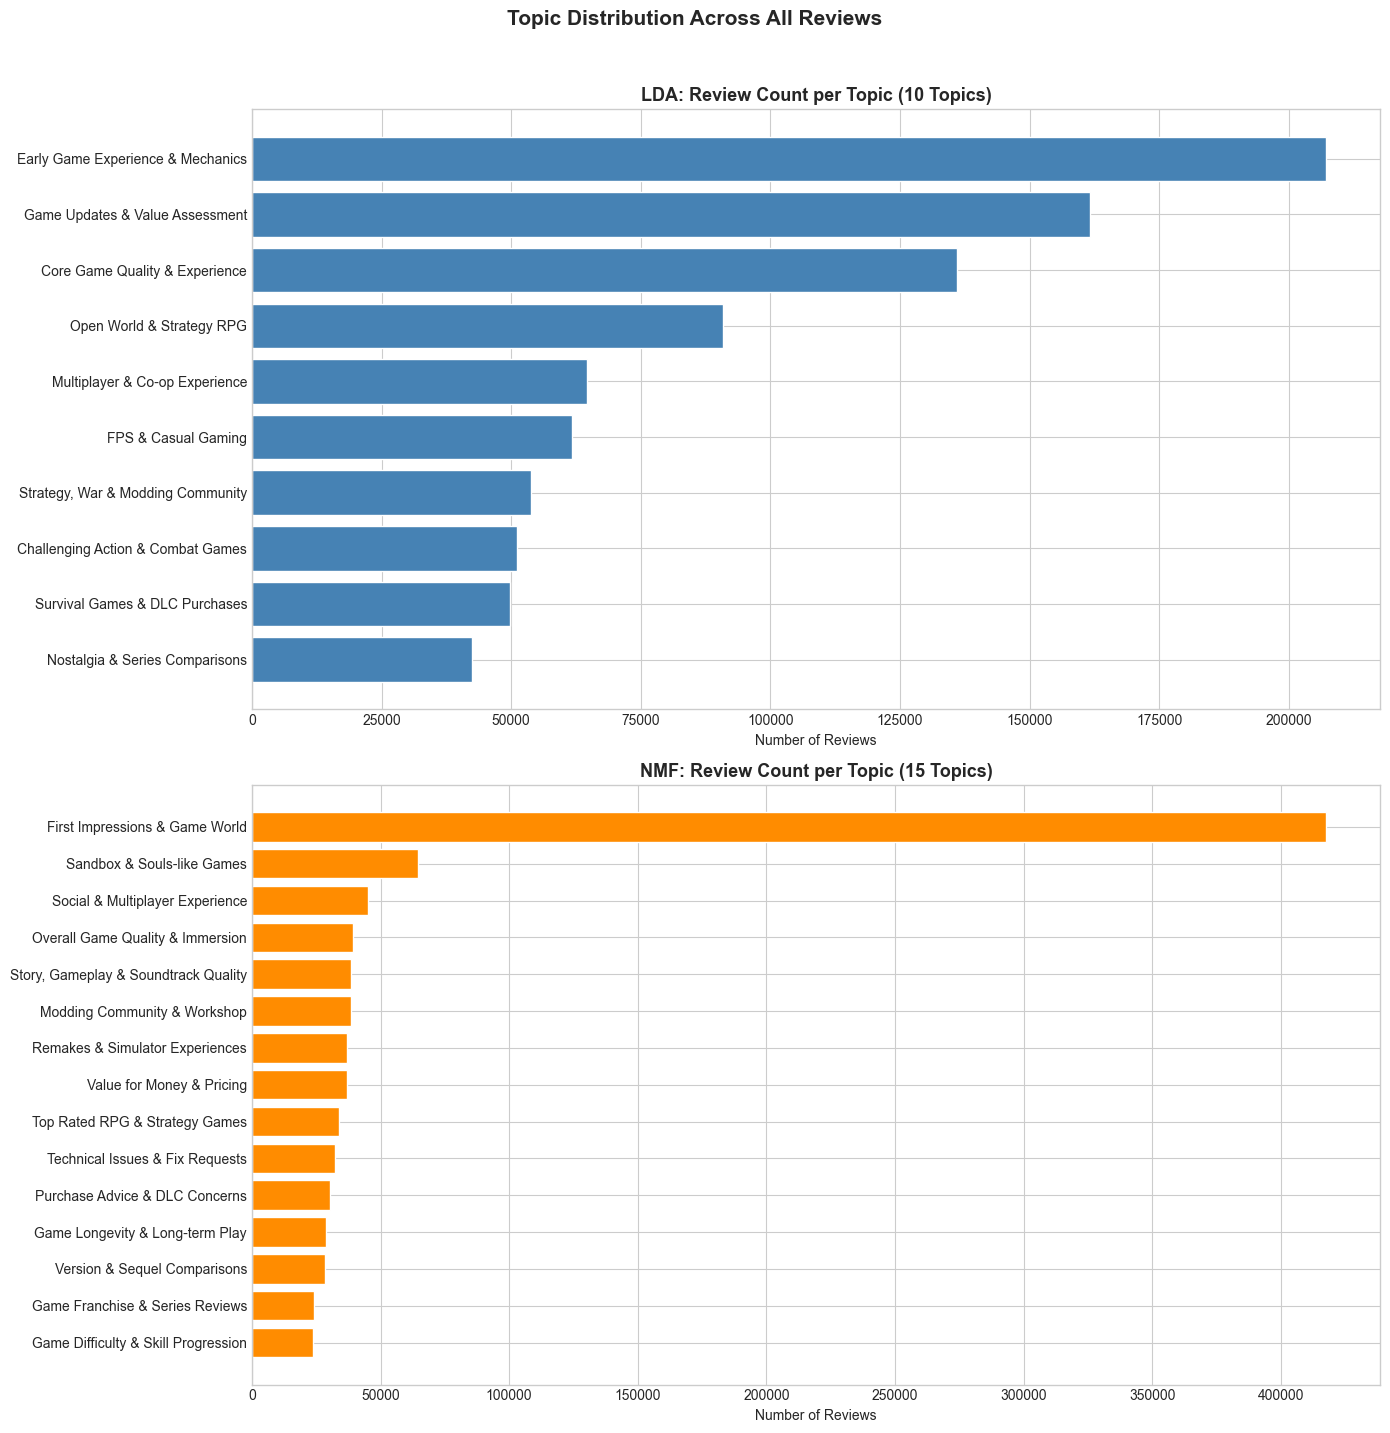

In [73]:

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

lda_dist = df['lda_topic_label'].value_counts()
axes[0].barh(lda_dist.index, lda_dist.values,
             color='steelblue', edgecolor='white')
axes[0].set_title('LDA: Review Count per Topic (10 Topics)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].invert_yaxis()

nmf_dist = df['nmf_topic_label'].value_counts()
axes[1].barh(nmf_dist.index, nmf_dist.values,
             color='darkorange', edgecolor='white')
axes[1].set_title('NMF: Review Count per Topic (15 Topics)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].invert_yaxis()

plt.suptitle('Topic Distribution Across All Reviews',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

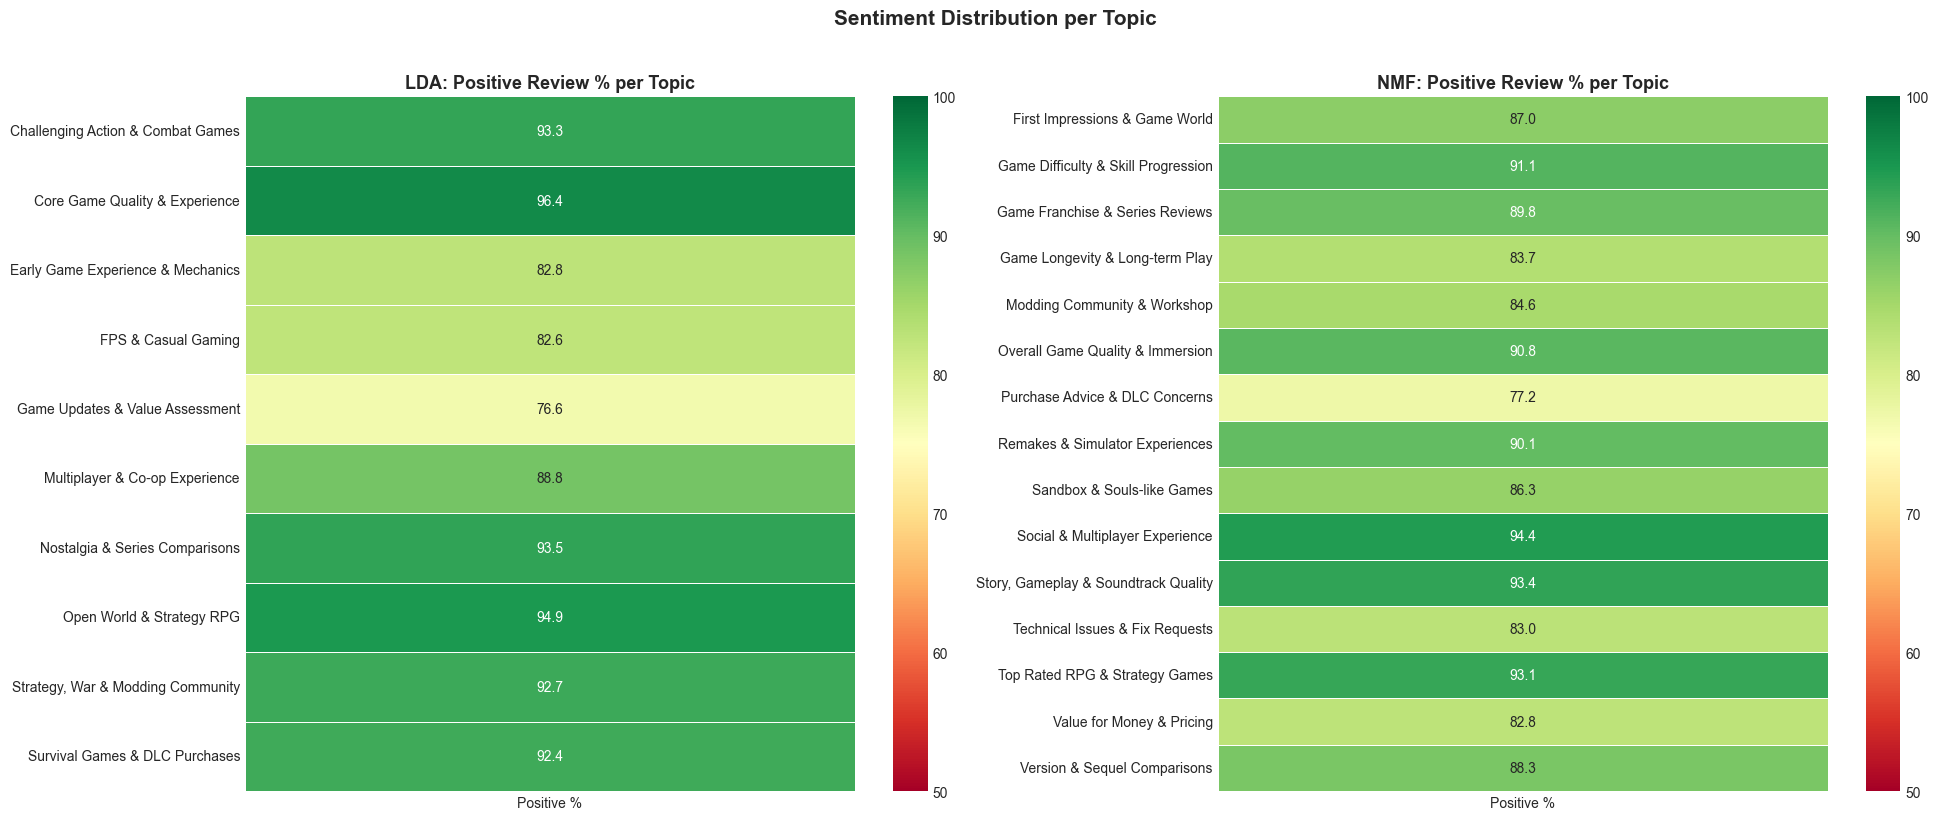

In [74]:

lda_sentiment = pd.crosstab(
    df['lda_topic_label'],
    df['recommended'],
    normalize='index'
).mul(100).round(1)
lda_sentiment.columns = ['Negative %', 'Positive %']

nmf_sentiment = pd.crosstab(
    df['nmf_topic_label'],
    df['recommended'],
    normalize='index'
).mul(100).round(1)
nmf_sentiment.columns = ['Negative %', 'Positive %']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(lda_sentiment[['Positive %']],
            annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=50, vmax=100,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('LDA: Positive Review % per Topic',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

sns.heatmap(nmf_sentiment[['Positive %']],
            annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=50, vmax=100,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('NMF: Positive Review % per Topic',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Sentiment Distribution per Topic',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Save Notebook 4 Checkpoint

We save the updated dataset with LDA and NMF topic assignments. These topic columns will be used as features in Notebook 5 where topic membership serves as an input to our helpfulness and recommendation prediction models.

In [75]:
output_path = '../data/steam_text_mining_nb4.parquet'
df.to_parquet(output_path, index=False)

print(f"Saved : steam_text_mining_nb4.parquet")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")
print(f"Size    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Saved : steam_text_mining_nb4.parquet
Rows    : 919,083
Columns : ['review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours', 'review_cleaned', 'review_cleaned_sentiment', 'word_count_raw', 'word_count_cleaned', 'word_count_conservative', 'ttr', 'is_helpful', 'lda_topic', 'lda_topic_label', 'nmf_topic', 'nmf_topic_label']
Size    : 709.5 MB


### Notebook 4 Summary

| Step | Detail |
|---|---|
| Dataset for training | Capped at 2,000 reviews per game |
| Full dataset rows | 919,083 |
| Capped dataset rows | 362,351 |
| Unique games | 315 |
| Vocabulary size | 10,000 words (both models) |
| Negation words excluded | 21 words (vectorizer level) |
| Sentiment words excluded | 55 words (vectorizer level) |
| Total vectorizer exclusions | 76 words |
| LDA topics | 10 |
| NMF topics | 15 |
| LDA perplexity | 2,741.02 |
| LDA coherence (C_v) | 0.4722 (Acceptable) |
| NMF coherence (C_v) | 0.5121 (Good) |
| Better performing model | NMF (by 0.0400) |

**LDA Topics Discovered (10):**

| Topic | Label | Key Words |
|---|---|---|
| 1 | Open World & Strategy RPG | world, map, quest, combat, turn, building |
| 2 | Game Updates & Value Assessment | worth, bug, update, issue, money, content |
| 3 | Early Game Experience & Mechanics | enemy, first, feel, find, weapon, system |
| 4 | Multiplayer & Co-op Experience | friend, coop, online, multiplayer, mode |
| 5 | Core Game Quality & Experience | story, character, gameplay, graphic, music |
| 6 | Challenging Action & Combat Games | dark, soul, hard, die, gun, warhammer |
| 7 | Strategy, War & Modding Community | mod, war, community, server, battle, rts |
| 8 | Nostalgia & Series Comparisons | old, voice, finished, franchise, fan |
| 9 | FPS & Casual Gaming | fps, screen, funny, glitch, card |
| 10 | Survival Games & DLC Purchases | dlc, survival, zombie, buy, cry |

**NMF Topics Discovered (15):**

| Topic | Label | Key Words |
|---|---|---|
| 1 | First Impressions & Game World | first, new, feel, character, level, world |
| 2 | Top Rated RPG & Strategy Games | greatest, rpg, strategy, simulator, indie |
| 3 | Social & Multiplayer Experience | friend, coop, solo, online, laugh, family |
| 4 | Sandbox & Souls-like Games | minecraft, soul, dark, skyrim, park |
| 5 | Purchase Advice & DLC Concerns | dlc, regret, sale, suck, bought |
| 6 | Story, Gameplay & Soundtrack Quality | story, character, combat, music, ending |
| 7 | Value for Money & Pricing | worth, price, penny, dollar, cent, buck |
| 8 | Version & Sequel Comparisons | original, csgo, pubg, fortnite, gta |
| 9 | Game Difficulty & Skill Progression | hard, easy, master, rewarding, challenge |
| 10 | Modding Community & Workshop | mod, workshop, skyrim, paid, download |
| 11 | Overall Game Quality & Immersion | graphic, addictive, storyline, smooth |
| 12 | Technical Issues & Fix Requests | bug, fix, update, server, help |
| 13 | Game Longevity & Long-term Play | year, ago, release, classic, past |
| 14 | Game Franchise & Series Reviews | total war, warhammer, far cry, rome |
| 15 | Remakes & Simulator Experiences | remake, ruined, valve, episode, wasted |

**Key Observations:**

1. **Methodology Impact: Three Fixes Improved Coherence:**
   Applying three methodological improvements over the initial run
   produced measurable gains in topic quality:
   - Per-game capping (2,000 max): fairer genre representation
   - Negation exclusion from vectorizers: removed language noise
   - Sentiment exclusion from vectorizers: revealed true themes
   
   Result: LDA improved from 0.4445 to 0.4722, NMF improved from
   0.4617 to 0.5121, with NMF crossing into the Good (0.5+) range.

2. **NMF Outperforms LDA:** NMF achieved a coherence score of 0.5121 vs LDA's 0.4722, a difference of 0.0400. NMF's use of TF-IDF weighting produced more semantically distinct topics than LDA's
   probabilistic Bag of Words approach on this corpus.

3. **Consistent Themes Across Both Models:** Both models independently discovered overlapping themes, validating them as genuine patterns:
   - Multiplayer/social: LDA Topic 4 & NMF Topic 3
   - Game quality: LDA Topic 5 & NMF Topic 6 & 11
   - Technical issues: LDA Topic 2 & NMF Topic 12
   - Combat/difficulty: LDA Topic 6 & NMF Topic 9
   - Modding community: LDA Topic 7 & NMF Topic 10

4. **NMF Provides Greater Granularity:** With 15 topics, NMF discovered more specific themes that LDA merged together, separating "Value for Money" (Topic 7) from "Purchase Advice & DLC" (Topic 5),
   and "Game Franchise Reviews" (Topic 14) from "Version Comparisons" (Topic 8). This granularity provides richer features for Notebook 5.

5. **Dominant Topic Limitation:** Both models show one topic absorbing a disproportionate share of reviews, LDA Topic 3 (22.5%) and NMF Topic 1 (45.4%). Both are anchored by generic words (like, feel,
   first, new) that appear across many review types. This is a known limitation of topic modeling on highly diverse corpora spanning multiple genres and game types.

6. **Game-Specific References Surface Clearly:** Without sentiment word interference, game-specific vocabulary emerged naturally.
   Total War, Warhammer, Far Cry (NMF Topic 14), CSGO, PUBG, Fortnite, GTA (NMF Topic 8), and Minecraft, Dark Souls, Skyrim (NMF Topic 4). This confirms the methodology improvements produced thematically meaningful results.

7. **Topic Assignment for Notebook 5:** Both lda_topic and nmf_topic are assigned to all 919,083 reviews and will serve as categorical features in Notebook 5's helpfulness and recommendation prediction
   models.

**Output:** `steam_text_mining_nb4.parquet`